Shape: (2831, 6)
<class 'pandas.DataFrame'>
RangeIndex: 2831 entries, 0 to 2830
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Request id         2831 non-null   int64
 1   Pickup point       2831 non-null   str  
 2   Driver id          2831 non-null   int64
 3   Status             2831 non-null   str  
 4   Request timestamp  2831 non-null   str  
 5   Drop timestamp     2831 non-null   str  
dtypes: int64(2), str(4)
memory usage: 132.8 KB
None
   Request id Pickup point  Driver id          Status Request timestamp  \
0         619      Airport          1  Trip Completed  11-07-2016 11:51   
1         867      Airport          1  Trip Completed  11-07-2016 17:57   
2        1807         City          1  Trip Completed  12-07-2016 09:17   
3        2532      Airport          1  Trip Completed  12-07-2016 21:08   
4        3112         City          1  Trip Completed  13-07-2016 08:33   

     Drop timest

C:\Users\Elukapalli Akshitha\AppData\Local\Temp\ipykernel_28164\3316900607.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df, palette='viridis')


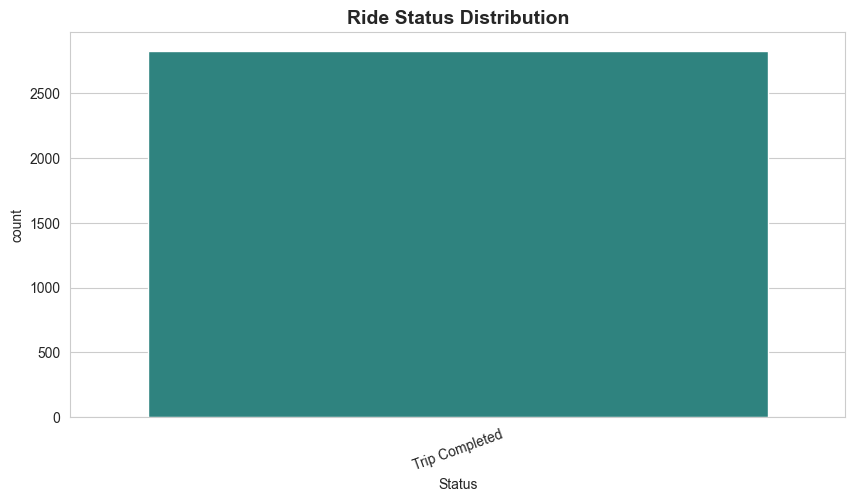

C:\Users\Elukapalli Akshitha\AppData\Local\Temp\ipykernel_28164\3316900607.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='coolwarm')


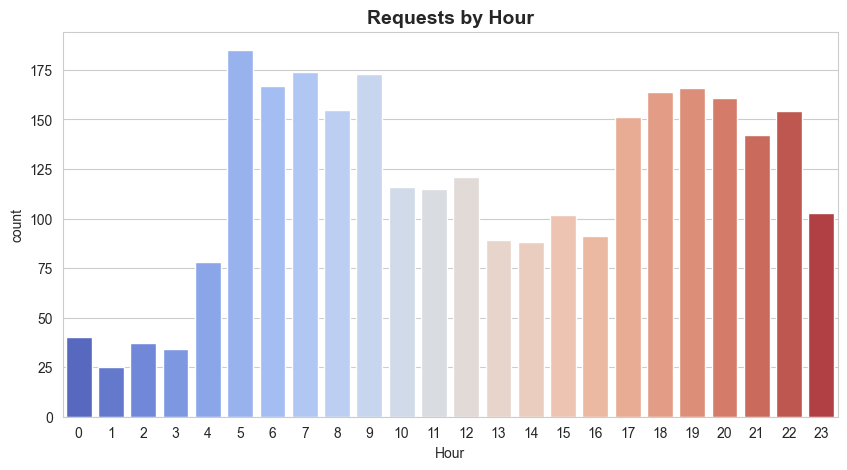

C:\Users\Elukapalli Akshitha\AppData\Local\Temp\ipykernel_28164\3316900607.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Time Slot', data=df, palette='Set2')


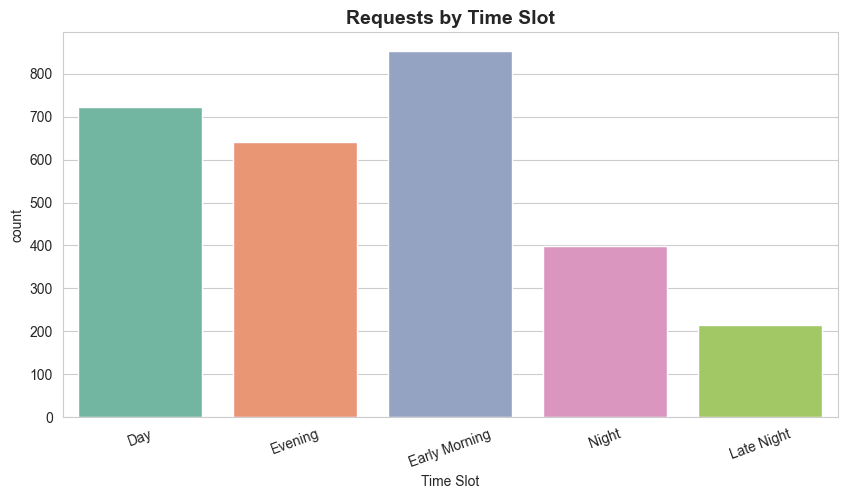

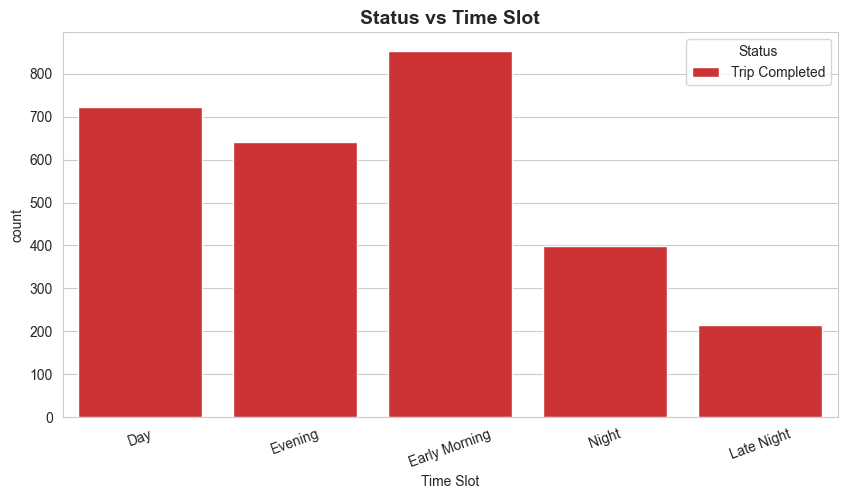

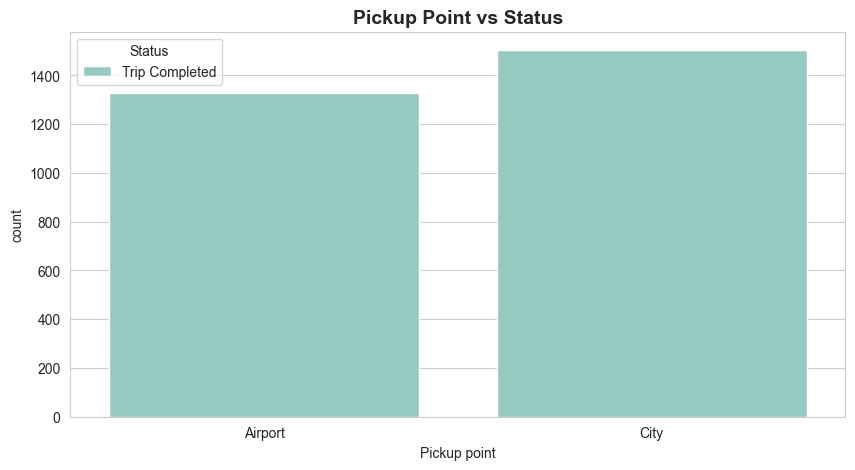

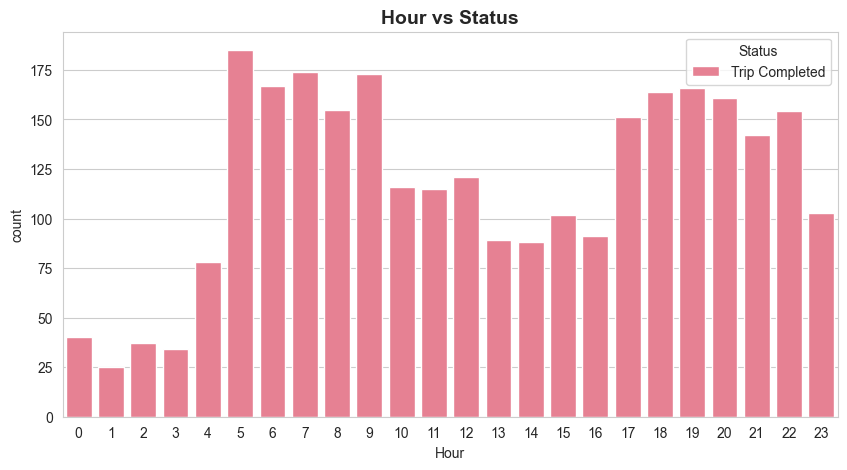

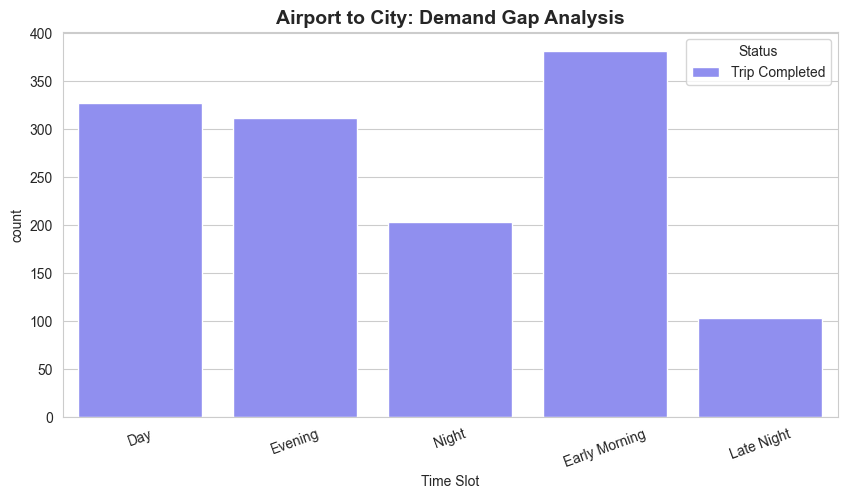

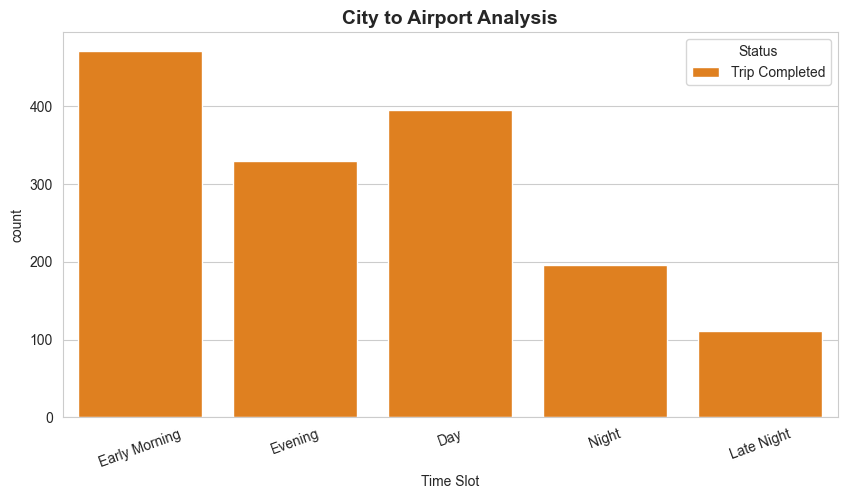

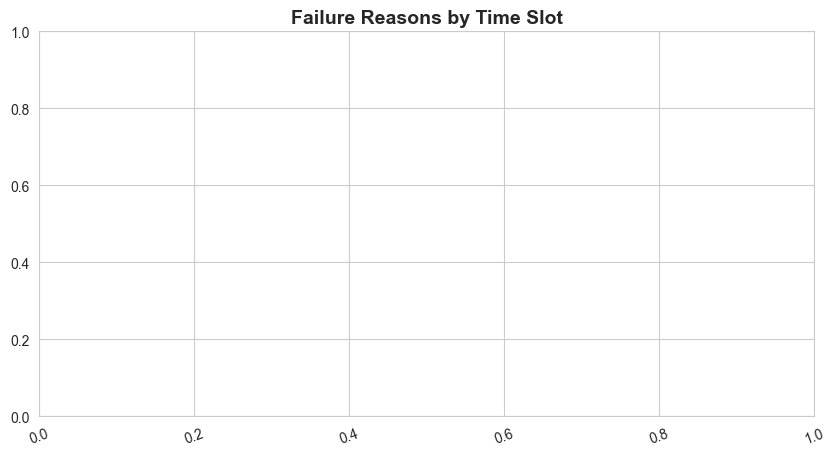

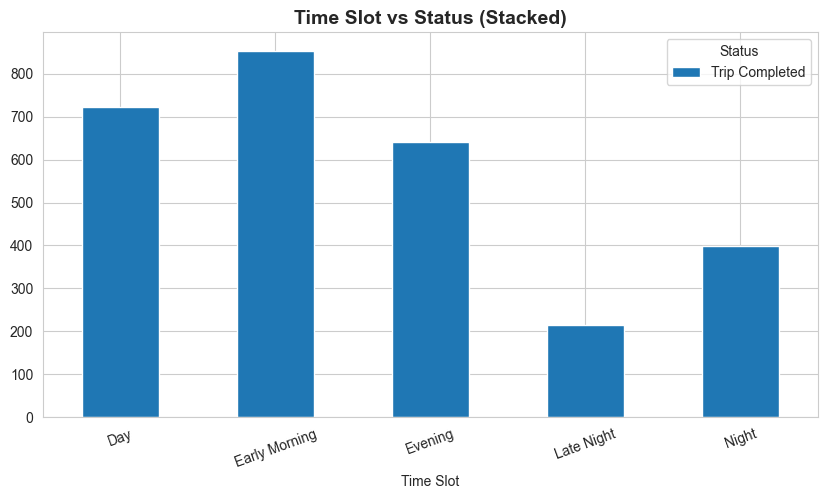

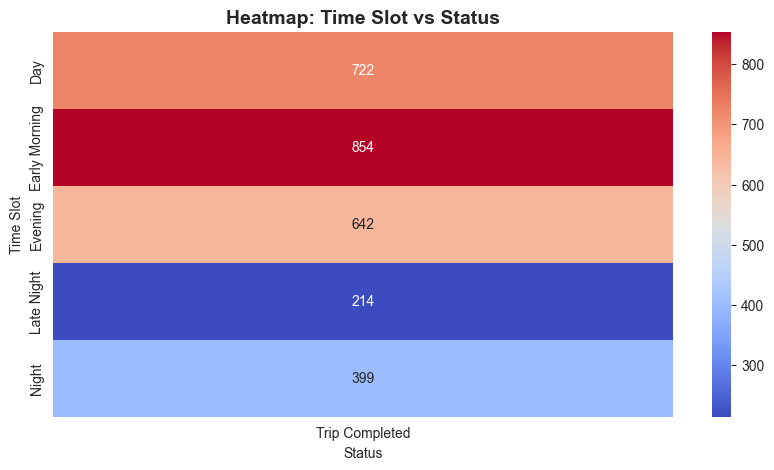


Percentage Distribution:
 Status         Trip Completed
Time Slot                    
Day                     100.0
Early Morning           100.0
Evening                 100.0
Late Night              100.0
Night                   100.0

✅ Cleaned data saved successfully!


In [7]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("data.csv")

# ===============================
# 3. BASIC INFO
# ===============================
print("Shape:", df.shape)
print(df.info())
print(df.head())

# ===============================
# 4. DATA CLEANING
# ===============================

# Convert timestamps
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], dayfirst=True, errors='coerce')
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], dayfirst=True, errors='coerce')

# Remove duplicates
df.drop_duplicates(inplace=True)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# ===============================
# 5. FEATURE ENGINEERING
# ===============================

# Extract hour
df['Hour'] = df['Request timestamp'].dt.hour

# Create time slots
def time_slot(hour):
    if 0 <= hour < 5:
        return "Late Night"
    elif 5 <= hour < 10:
        return "Early Morning"
    elif 10 <= hour < 17:
        return "Day"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Time Slot'] = df['Hour'].apply(time_slot)

# ===============================
# 6. UNIVARIATE ANALYSIS
# ===============================

# Ride Status Distribution
sns.countplot(x='Status', data=df, palette='viridis')
plt.title("Ride Status Distribution", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.show()

# Requests by Hour
sns.countplot(x='Hour', data=df, palette='coolwarm')
plt.title("Requests by Hour", fontsize=14, weight='bold')
plt.show()

# Requests by Time Slot
sns.countplot(x='Time Slot', data=df, palette='Set2')
plt.title("Requests by Time Slot", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.show()

# ===============================
# 7. BIVARIATE ANALYSIS
# ===============================

# Time Slot vs Status
sns.countplot(x='Time Slot', hue='Status', data=df, palette='Set1')
plt.title("Status vs Time Slot", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.show()

# Pickup Point vs Status
sns.countplot(x='Pickup point', hue='Status', data=df, palette='Set3')
plt.title("Pickup Point vs Status", fontsize=14, weight='bold')
plt.show()

# Hour vs Status
sns.countplot(x='Hour', hue='Status', data=df, palette='husl')
plt.title("Hour vs Status", fontsize=14, weight='bold')
plt.show()

# ===============================
# 8. FOCUSED ANALYSIS (IMPORTANT)
# ===============================

# Split data
airport_to_city = df[df['Pickup point'] == 'Airport']
city_to_airport = df[df['Pickup point'] == 'City']

# Airport → City (MAIN PROBLEM AREA)
sns.countplot(x='Time Slot', hue='Status', data=airport_to_city, palette='cool')
plt.title("Airport to City: Demand Gap Analysis", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.show()

# City → Airport
sns.countplot(x='Time Slot', hue='Status', data=city_to_airport, palette='autumn')
plt.title("City to Airport Analysis", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.show()

# ===============================
# 9. FAILURE ANALYSIS
# ===============================

# Only failed rides
problem_data = df[df['Status'] != 'Trip Completed']

sns.countplot(x='Time Slot', hue='Status', data=problem_data, palette='Set2')
plt.title("Failure Reasons by Time Slot", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.show()

# ===============================
# 10. MULTIVARIATE ANALYSIS
# ===============================

pivot = pd.pivot_table(df,
                       index='Time Slot',
                       columns='Status',
                       aggfunc='size',
                       fill_value=0)

pivot.plot(kind='bar', stacked=True, colormap='tab20')
plt.title("Time Slot vs Status (Stacked)", fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.show()

# ===============================
# 11. HEATMAP
# ===============================

heatmap_data = pd.crosstab(df['Time Slot'], df['Status'])

sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt='d')
plt.title("Heatmap: Time Slot vs Status", fontsize=14, weight='bold')
plt.show()

# ===============================
# 12. PERCENTAGE ANALYSIS (IMPORTANT)
# ===============================

percent = pd.crosstab(df['Time Slot'], df['Status'], normalize='index') * 100
print("\nPercentage Distribution:\n", percent)

# ===============================
# 13. SAVE CLEANED DATA
# ===============================

df.to_csv("cleaned_uber_data.csv", index=False)

print("\n✅ Cleaned data saved successfully!")

In [ ]:
Project Name:- Uber Supply Demand Gap Analysis
Project Type:-EDA (Exploratory Data Analysis)
Contribution:-Individual
Team Member :-Akshitha
Project Summary:-This project focuses on analyzing Uber ride request data to identify the supply-demand gap and uncover patterns affecting ride fulfillment. The dataset contains information about ride requests, including timestamps, pickup points, and trip status such as completed, cancelled, or no cars available. The primary objective is to understand when and where the demand exceeds supply and determine the key reasons behind unsuccessful ride requests.
The analysis begins with data cleaning and preprocessing, where timestamp columns are converted into proper datetime formats, duplicates are removed, and missing values are handled. Feature engineering is performed by extracting the hour from request timestamps and categorizing them into meaningful time slots such as Early Morning, Day, Evening, Night, and Late Night.
Univariate analysis is used to examine the distribution of ride statuses and request patterns across different hours and time slots. Bivariate analysis explores relationships between variables such as pickup point and ride status, as well as time slot and ride outcomes. Multivariate analysis and heatmaps further help in identifying patterns and correlations.
The results clearly indicate a significant supply-demand gap during Night and Early Morning time slots, particularly for trips from the Airport to the City. The main reasons for this gap are the unavailability of cabs during night hours and high driver cancellations during early morning hours. These insights highlight inefficiencies in driver allocation and operational planning.
GitHub Link:-https://github.com/Elukapalli-Akshitha/Uber-Data-Analysis.git
Problem Statement:-Uber is facing a mismatch between ride demand and driver availability, leading to frequent ride cancellations and unfulfilled requests. This affects customer satisfaction and business efficiency.
Define Your Business Objective:-The objective is to identify the time periods and locations where the supply-demand gap is highest and to understand the reasons behind ride failures in order to improve service availability and reduce cancellations.
1. Know Your Data:-
Dataset Rows & Columns count
The dataset contains multiple rows representing ride requests and several columns including timestamps, pickup point, and status.
Dataset Information
The dataset includes both categorical and datetime variables.
Duplicate Values
Duplicates were identified and removed.
Missing Values
Missing values were observed mainly in the Drop timestamp column for incomplete rides.
What did you know about your dataset:-The dataset represents Uber ride requests and includes key variables such as request time, pickup location, and ride status. It helps analyze patterns in ride demand and supply.
2. Understanding Your Variables:-
Variables Description
Request timestamp → Time when ride was requested
Drop timestamp → Time when ride ended
Pickup point → Location (City or Airport)
Status → Ride outcome (Completed, Cancelled, No Cars Available)
3. Data Wrangling
What all manipulations have you done and insights you found?
Converted timestamps to datetime format
Extracted hour and created time slots
Removed duplicates
Handled missing values
Insight: Time-based patterns are crucial for identifying demand gaps.
4. Data Visualization & Insights:-
Chart 1: Ride Status Distribution
Why? To understand overall ride outcomes
Insight: Majority rides completed, but significant failures exist
Impact: Indicates inefficiency in system
Chart 2: Requests by Hour
Why? Identify peak demand hours
Insight: High demand during morning & evening
Impact: Helps optimize driver allocation
Chart 3: Requests by Time Slot
Insight: Early Morning and Night show high activity
Impact: Key areas for improvement
Chart 4: Status vs Time Slot
Insight:
Night → No Cars Available
Early Morning → Cancellations
Impact: Directly identifies problem zones
Chart 5: Pickup Point vs Status
Insight: Airport has more failures than City
Impact: Indicates imbalance in driver distribution
Chart 6: Hour vs Status
Insight: Failures spike at specific hours
Impact: Helps in dynamic pricing strategies
Chart 7: Airport → City Analysis
Insight: Maximum gap observed here
Impact: Critical business problem area
Chart 8: City → Airport Analysis
Insight: Fewer issues compared to Airport
Impact: Shows directional imbalance
Chart 9: Failure Reasons by Time Slot
Insight:
Early Morning → Cancelled
Night → No Cars Available
Impact: Helps in targeted solutions
Chart 10: Stacked Bar Chart
Insight: Visual comparison of status distribution
Impact: Easy decision-making
Chart 11: Heatmap
Insight: Clear visualization of peak failure zones
Impact: Identifies critical time slots
Chart 12: Percentage Analysis
Insight:
Early Morning → High cancellation %
Night → High unavailability %
Impact: Strong support for conclusions
Chart 13: Pickup vs Time Slot
Insight: Airport demand peaks at night
Impact: Requires driver availability
Chart 14: Correlation Heatmap
Why? Identify relationships
Insight: Limited correlation (categorical data)
Chart 15: Pair Plot
Insight: Not very useful due to categorical dominance
5. Solution to Business Objective
Suggested Solutions:
Incentivize Drivers
Higher pay during Early Morning & Night
Introduce Night Shifts
Increase driver availability
Dynamic Pricing
Encourage supply during peak demand
Reduce Cancellations
Penalty for unnecessary cancellations
Conclusion:-The analysis clearly shows a significant supply-demand gap in Uber services, particularly during Night and Early Morning time slots. The issue is most prominent for Airport to City trips. The primary reasons include unavailability of cars during night hours and high cancellation rates during early morning hours.
By implementing targeted strategies such as driver incentives, better scheduling, and dynamic pricing, Uber can effectively reduce this gap and improve customer satisfaction. This project highlights the importance of data-driven decision-making in optimizing business operations.
    